PROJECT GOAL: Create Predictive model for inventory forecasting so that service centre achieve JIT Standards.

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

LOAD DATASET

In [2]:
df=pd.read_csv("service_data.csv")
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text
0,30-05-17,30-05-17,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL
1,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL
2,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH
3,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES
4,02-06-17,31-05-17,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL


In [3]:
df.shape

(28482, 7)

In [4]:
df.isnull().sum()

invoice_date              0
job_card_date             0
business_partner_name     0
vehicle_no                0
vehicle_model             0
current_km_reading        0
invoice_line_text        34
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  int64 
 6   invoice_line_text      28448 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.5+ MB


In [6]:
df.describe()

,current_km_reading
count,28482.000000
mean,19348.003827
std,25246.722306
min,0.000000
25%,3988.000000
50%,12420.500000
75%,27905.000000
max,610112.000000


In [7]:
#Convert date Column
df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d-%m-%y',errors='coerce')

EXPLORATORY DATA ANALYSIS

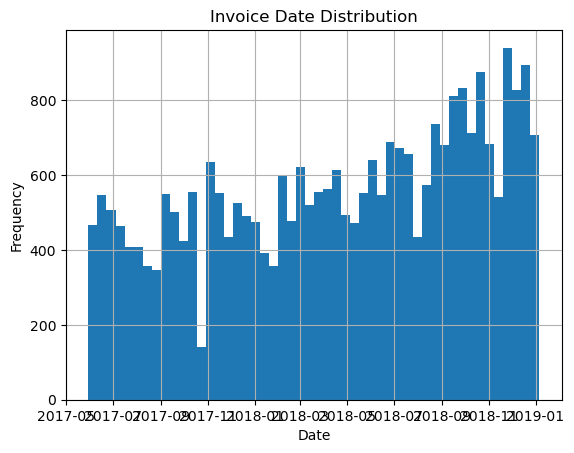

In [8]:
#invoice date distribution
import matplotlib.pyplot as plt
df['invoice_date'].hist(bins=50)
plt.title("Invoice Date Distribution")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.show()

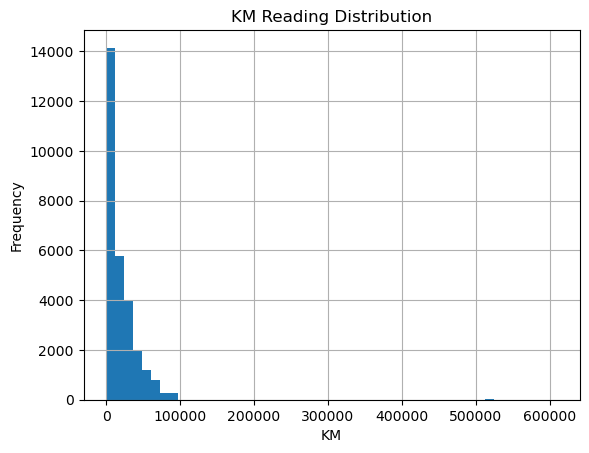

In [9]:
#Current KM Reading Distribution
df['current_km_reading'].hist(bins=50)
plt.title("KM Reading Distribution")
plt.xlabel("KM")
plt.ylabel("Frequency")
plt.show()

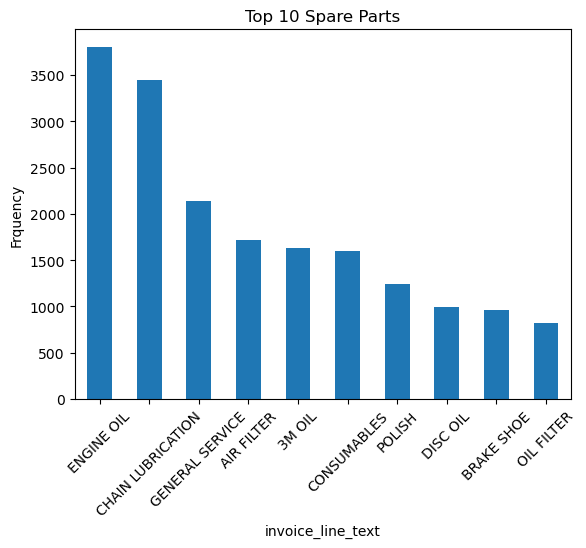

In [10]:
#Frequency invoice_line_text
top_items=df['invoice_line_text'].value_counts().head(10)
top_items.plot(kind='bar')
plt.title("Top 10 Spare Parts")
plt.xlabel("invoice_line_text")
plt.ylabel("Frquency")
plt.xticks(rotation=45)
plt.show()

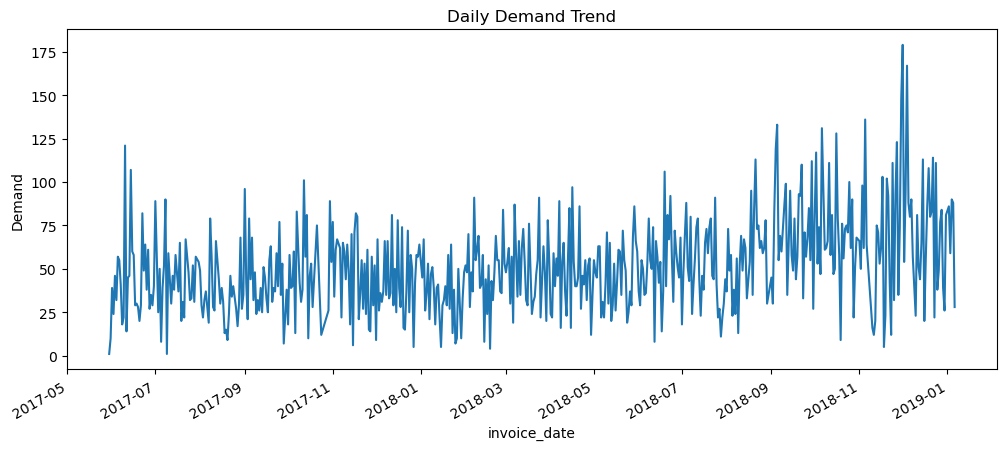

In [11]:
#Demand Before Aggregation
df['demand'] = 1
daily_demand=df.groupby('invoice_date')['demand'].sum()
daily_demand.plot(figsize=(12,5))
plt.title("Daily Demand Trend")
plt.xlabel("invoice_date")
plt.ylabel("Demand")
plt.show()

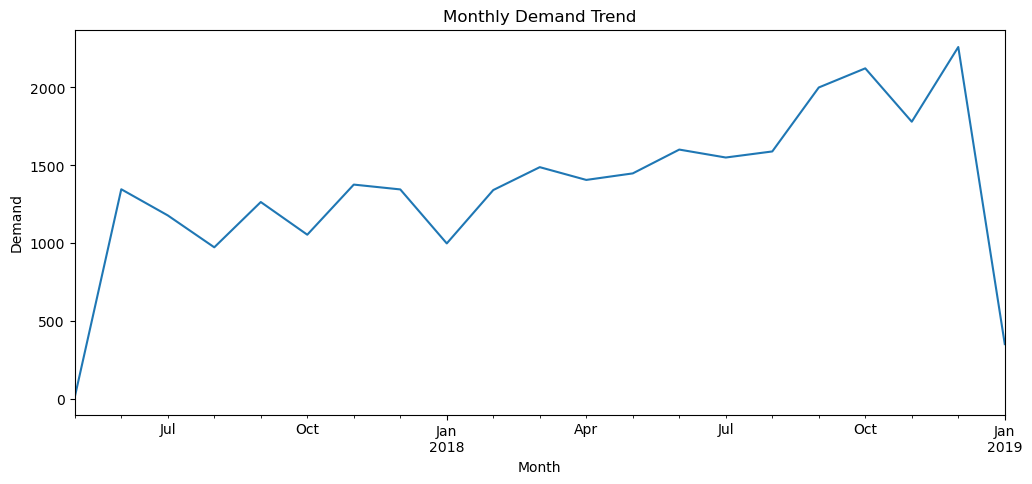

In [12]:
#Monthly Trend
df['month'] = df['invoice_date'].dt.to_period('M')

monthly_demand = df.groupby('month')['demand'].sum()

monthly_demand.plot(figsize=(12,5))
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.show()

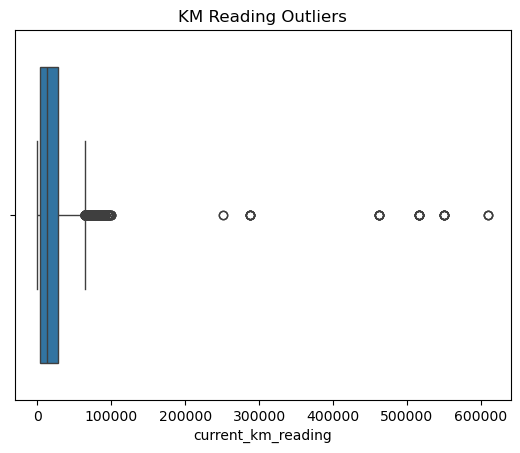

In [13]:
#Outlier Detection
import seaborn as sns
sns.boxplot(x=df['current_km_reading'])
plt.title("KM Reading Outliers")
plt.show()

DATA CLEANING

In [14]:
df = df.dropna(subset=["invoice_date", "invoice_line_text"])

df["job_card_date"] = pd.to_datetime(df["job_card_date"], format="%d-%m-%Y", errors="coerce")

# Fill missing KM
df["current_km_reading"] = df["current_km_reading"].fillna(df["current_km_reading"].median())

EXTRACT SPARE PARTS

In [15]:
df["invoice_line_text"] = df["invoice_line_text"].str.lower()

# Optional: clean text
df["invoice_line_text"] = df["invoice_line_text"].str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)

In [16]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")

In [17]:
print(df["invoice_date"].dtype)

datetime64[ns]


In [18]:
df["invoice_date"] = df["invoice_date"].dt.to_period("D").apply(lambda r: r.start_time)

AGGREGATE DEMAND

In [19]:
df["invoice_date"] = df["invoice_date"].dt.to_period("D").apply(lambda r: r.start_time)

demand_df = df.groupby(["invoice_line_text", "invoice_date"]).size().reset_index(name="Demand")

print(demand_df.head())

  invoice_line_text invoice_date  Demand
0       10 size nut   2018-06-23       1
1       10 size nut   2018-09-10       1
2      12 size bolt   2018-08-28       1
3      12 size bolt   2018-09-04       1
4            3m oil   2017-05-31       2


FEATURE ENGINEERING

In [20]:
demand_df = demand_df.sort_values(by=["invoice_line_text", "invoice_date"])

# Lag features
for lag in [1, 2, 3, 4]:
    demand_df[f"lag_{lag}"] = demand_df.groupby("invoice_line_text")["Demand"].shift(lag)

# Rolling mean
demand_df["rolling_mean_4"] = demand_df.groupby("invoice_line_text")["Demand"].shift(1).rolling(4).mean()

demand_df = demand_df.dropna()

In [21]:
demand_df

,invoice_line_text,invoice_date,Demand,lag_1,lag_2,lag_3,lag_4,rolling_mean_4
8,3m oil,2017-06-04,3,2.0,3.0,5.0,2.0,3.00
9,3m oil,2017-06-05,2,3.0,2.0,3.0,5.0,3.25
10,3m oil,2017-06-06,4,2.0,3.0,2.0,3.0,2.50
11,3m oil,2017-06-07,4,4.0,2.0,3.0,2.0,2.75
12,3m oil,2017-06-08,2,4.0,4.0,2.0,3.0,3.25
...,...,...,...,...,...,...,...,...
12651,yoke,2018-08-20,1,1.0,1.0,1.0,1.0,1.00
12652,yoke,2018-10-09,1,1.0,1.0,1.0,1.0,1.00
12653,yoke,2018-10-11,1,1.0,1.0,1.0,1.0,1.00
12654,yoke,2018-11-24,1,1.0,1.0,1.0,1.0,1.00


Model Building

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [23]:
features = ["lag_1", "lag_2", "lag_3", "lag_4", "rolling_mean_4"]

In [24]:
X = demand_df[features]
y = demand_df["Demand"]

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

In [26]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [27]:
pred=lr.predict(X_test)

In [28]:
pred

array([2.03666869, 1.97421183, 2.0834196 , ..., 1.22972323, 1.22972323,
       1.22972323])

In [29]:
MAE=mean_absolute_error(y_test,pred)

In [30]:
print("Linear Regression MAE:",MAE)

Linear Regression MAE: 0.7195777379683418


RandomforestRegressor

In [31]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [32]:
pred=rf.predict(X_test)

In [33]:
pred

array([3.09212614, 2.1271411 , 2.50407971, ..., 1.15311768, 1.15311768,
       1.15311768])

In [34]:
MAE=mean_absolute_error(y_test,pred)

In [35]:
print("Random Forest MAE:",MAE)

Random Forest MAE: 0.7245642201836661


Hyperparameter Tuning

In [36]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

In [37]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

In [38]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='neg_mean_absolute_error')

In [39]:
best_rf=grid_search.best_estimator_

In [40]:
#Predictions with tuned model
pred_rf_tuned=best_rf.predict(X_test)

In [41]:
pred_rf_tuned

array([2.26962009, 1.90220151, 2.32735741, ..., 1.15473487, 1.15473487,
       1.15473487])

In [42]:
MAE=mean_absolute_error(y_test,pred_rf_tuned)

In [43]:
print("Best Parameters:",grid_search.best_params_)
print("Tuned Random Forest MAE:",MAE)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Tuned Random Forest MAE: 0.6948374806001372


In [44]:
# Aggregate daily demand
ts_df = df.groupby('invoice_date')['demand'].sum().reset_index()

# Set date as index
ts_df = ts_df.set_index('invoice_date')

# Set frequency
ts_df = ts_df.asfreq('D')

# Sort index
ts_df = ts_df.sort_index()

print(ts_df.head())

              demand
invoice_date        
2017-05-30       1.0
2017-05-31      10.0
2017-06-01      39.0
2017-06-02      24.0
2017-06-03      46.0


Train-Test Split

In [54]:
train_size = int(len(ts_df) * 0.8)

train = ts_df[:train_size]
test = ts_df[train_size:]

Build SARIMA Model

In [55]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['demand'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52)
)

model_fit = model.fit()

print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             demand   No. Observations:                  469
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood               -1832.680
Date:                            Fri, 10 Apr 2026   AIC                           3675.361
Time:                                    16:17:43   BIC                           3695.514
Sample:                                05-30-2017   HQIC                          3683.329
                                     - 09-10-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0616      0.059     -1.035      0.301      -0.178       0.055
ma.L1         -0.9412      0.022   

In [56]:
forecast = model_fit.forecast(steps=len(test))

forecast = pd.Series(forecast, index=test.index)

In [57]:
forecast

invoice_date
2018-09-11    71.458050
2018-09-12    65.560152
2018-09-13    61.674350
2018-09-14    69.823644
2018-09-15    58.898713
                ...    
2019-01-02    78.471319
2019-01-03    77.526523
2019-01-04    70.047176
2019-01-05    77.042590
2019-01-06    78.428688
Freq: D, Name: predicted_mean, Length: 118, dtype: float64

In [59]:
test['demand'] = test['demand'].fillna(0)
forecast = pd.Series(forecast, index=test.index)
forecast = forecast.fillna(0)

C:\Users\nitin\AppData\Local\Temp\ipykernel_6308\3166308799.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['demand'] = test['demand'].fillna(0)


In [60]:
# Final check
print(test['demand'].isna().sum())
print(forecast.isna().sum())


0
0


In [61]:
from sklearn.metrics import mean_absolute_error

mae_sarima = mean_absolute_error(test['demand'], forecast)

print("SARIMA MAE:", mae_sarima)

SARIMA MAE: 29.55261990030935


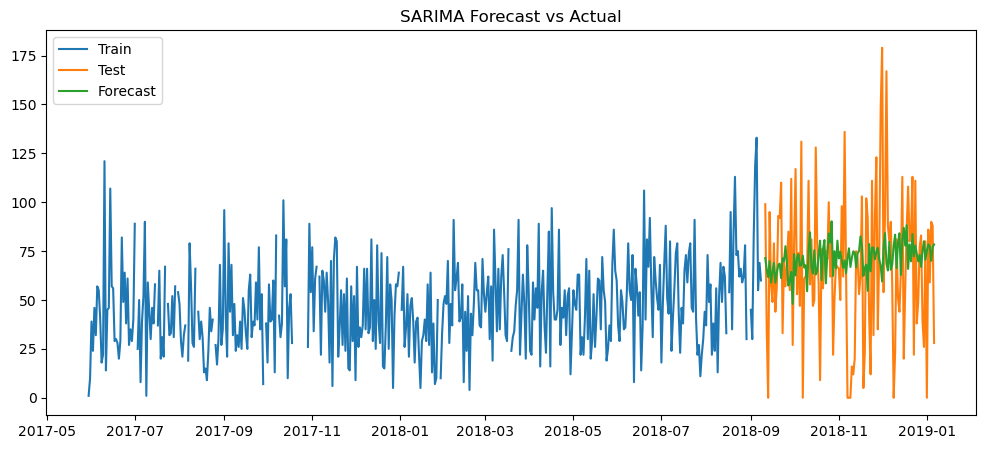

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(train.index, train['demand'], label='Train')
plt.plot(test.index, test['demand'], label='Test')
plt.plot(forecast.index, forecast, label='Forecast')

plt.legend()
plt.title("SARIMA Forecast vs Actual")
plt.show()

Conclusion:
this project developing on forecasting spare parts demand using service data.
Multiple models, including Linear Regression,Random Forest Regressor, SARIMA were 
implemented and evaluated using Mean Absolute Error(MAE) as the performance metric.